# Explainability Maps — Grad-CAM and Attention Rollout

Runs on MacBook (MPS) using the best baseline checkpoint.
Generates and saves maps for all 202 validation images.

**Outputs**
- `maps/gradcam/gradcam_maps.npy` — shape [202, 14, 14, 14] (images × labels × h × w at 14×14)
- `maps/rollout/rollout_maps.npy` — shape [202, 14, 14] (images × h × w)
- `maps/visualizations/` — qualitative overlay PNGs for gate check

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path('..').resolve()))

import json
import numpy as np
import pandas as pd
import torch
import timm
import cv2
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image
from torch.utils.data import DataLoader
from tqdm import tqdm
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

from src.config import PROJECT_ROOT, IMAGE_ROOT, SPLITS_DIR, CKPT_DIR
from src.dataset import LABEL_COLS, CheXpertDataset, eval_transforms

MAPS_DIR  = PROJECT_ROOT / 'maps'
VIZ_DIR   = MAPS_DIR / 'visualizations'
VIZ_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = (
    torch.device('cuda') if torch.cuda.is_available()
    else torch.device('mps') if torch.backends.mps.is_available()
    else torch.device('cpu')
)
print('Device:', DEVICE)

Device: mps


## 1. Load best baseline checkpoint

In [2]:
# Pick seed with highest macro AUC from saved results
results_csv = CKPT_DIR / 'baseline_results.csv'
seeds = [42, 123, 456]

if results_csv.exists():
    # Load per-seed macro AUC from checkpoints directly
    best_seed, best_auc = None, 0.0
    for seed in seeds:
        ckpt_path = CKPT_DIR / f'baseline_seed{seed}_best.pt'
        if ckpt_path.exists():
            ckpt = torch.load(ckpt_path, map_location='cpu', weights_only=False)
            auc = ckpt['val_macro_auc']
            print(f'  seed {seed}: macro AUC {auc:.4f}')
            if auc > best_auc:
                best_auc, best_seed = auc, seed
    print(f'\nUsing seed {best_seed} (macro AUC {best_auc:.4f})')
else:
    best_seed = 42
    print('No results CSV found — defaulting to seed 42')

CKPT_PATH = CKPT_DIR / f'baseline_seed{best_seed}_best.pt'

  seed 42: macro AUC 0.7828
  seed 123: macro AUC 0.7970
  seed 456: macro AUC 0.7950

Using seed 123 (macro AUC 0.7970)


In [3]:
MODEL_NAME = 'vit_base_patch16_224.augreg_in21k'

def load_model(ckpt_path):
    model = timm.create_model(MODEL_NAME, pretrained=False, num_classes=14)
    ckpt = torch.load(ckpt_path, map_location='cpu', weights_only=False)
    model.load_state_dict(ckpt['model_state_dict'])
    model.eval()
    return model.to(DEVICE)

model = load_model(CKPT_PATH)
print('Model loaded. Blocks:', len(model.blocks))

Model loaded. Blocks: 12


In [4]:
# Validation dataset — eval transforms, returns original dims
df_valid = pd.read_csv(SPLITS_DIR / 'valid_frontal.csv')
val_ds   = CheXpertDataset(df_valid, IMAGE_ROOT, eval_transforms)

# Single-image loader for map generation (need per-image control)
val_loader = DataLoader(val_ds, batch_size=1, shuffle=False, num_workers=0)
print(f'Validation images: {len(val_ds)}')

Validation images: 202


## 2. Grad-CAM

Target layer: `model.blocks[-1].norm1` (output of last transformer block, before MLP).
The `reshape_transform` drops the CLS token and reshapes the remaining 196 patch tokens
from [B, 196, 768] into [B, 768, 14, 14] so pytorch-grad-cam can apply standard CAM logic.
One map per pathology label per image. Saved at 14×14 before upsampling.

In [5]:
def reshape_transform(tensor, height=14, width=14):
    """Convert [B, N+1, D] ViT output to [B, D, H, W] for pytorch-grad-cam."""
    result = tensor[:, 1:, :]                                         # drop CLS → [B, 196, 768]
    result = result.reshape(result.size(0), height, width, -1)        # [B, 14, 14, 768]
    result = result.permute(0, 3, 1, 2)                               # [B, 768, 14, 14]
    return result


cam = GradCAM(
    model=model,
    target_layers=[model.blocks[-1].norm1],
    reshape_transform=reshape_transform,
)

N_VAL     = len(val_ds)
N_LABELS  = len(LABEL_COLS)
# Store raw 14×14 maps — upsample on demand during visualization
gradcam_maps = np.zeros((N_VAL, N_LABELS, 14, 14), dtype=np.float32)

for img_idx, (imgs, labels, *_) in enumerate(tqdm(val_loader, desc='Grad-CAM')):
    imgs = imgs.to(DEVICE)

    for label_idx in range(N_LABELS):
        targets = [ClassifierOutputTarget(label_idx)]
        # pytorch-grad-cam returns [B, H, W] upsampled to input size
        cam_224 = cam(input_tensor=imgs, targets=targets)    # [1, 224, 224]
        # Downsample back to 14×14 to save storage
        cam_14 = cv2.resize(cam_224[0], (14, 14), interpolation=cv2.INTER_AREA)
        gradcam_maps[img_idx, label_idx] = cam_14

save_path = MAPS_DIR / 'gradcam' / 'gradcam_maps.npy'
np.save(save_path, gradcam_maps)
print(f'\nSaved: {save_path}  shape: {gradcam_maps.shape}')

Grad-CAM: 100%|██████████| 202/202 [01:23<00:00,  2.41it/s]


Saved: /Users/davidone/fac/diz/dizertatie_project/maps/gradcam/gradcam_maps.npy  shape: (202, 14, 14, 14)


## 3. Attention Rollout

Disables fused attention so we can hook `attn_drop` and capture [B, heads, N, N] weights.
Applies the Abnar & Zuidema (2020) rollout: average heads → add identity → normalize rows
→ multiply sequentially across all 12 blocks → extract CLS row → reshape 14×14.

In [6]:
def compute_rollout(model, img_tensor):
    """
    Returns attention rollout map [B, 14, 14].
    Temporarily disables fused attention to expose weights via hooks.
    """
    # Disable fused attention for all blocks
    for block in model.blocks:
        block.attn.fused_attn = False

    attn_weights = {}
    hooks = []

    def make_hook(idx):
        def hook(module, input, output):
            # output: [B, num_heads, N, N] post-softmax attention weights
            attn_weights[idx] = output.detach().cpu()
        return hook

    for i, block in enumerate(model.blocks):
        hooks.append(block.attn.attn_drop.register_forward_hook(make_hook(i)))

    with torch.no_grad():
        _ = model(img_tensor)

    for h in hooks:
        h.remove()

    # Re-enable fused attention
    for block in model.blocks:
        block.attn.fused_attn = True

    B  = img_tensor.shape[0]
    N  = 197   # 1 CLS + 196 patch tokens
    I  = torch.eye(N)   # identity for residual connection

    rollout = I.unsqueeze(0).expand(B, -1, -1).clone()   # [B, N, N]

    for i in range(len(model.blocks)):
        attn  = attn_weights[i].mean(dim=1)              # avg over heads: [B, N, N]
        attn  = 0.5 * attn + 0.5 * I                    # add identity (residual)
        attn  = attn / attn.sum(dim=-1, keepdim=True)   # normalize rows
        rollout = attn @ rollout                         # accumulate

    cls_attn = rollout[:, 0, 1:]                         # CLS→patches: [B, 196]
    return cls_attn.reshape(B, 14, 14).numpy()           # [B, 14, 14]


rollout_maps = np.zeros((N_VAL, 14, 14), dtype=np.float32)

for img_idx, (imgs, *_) in enumerate(tqdm(val_loader, desc='Attention Rollout')):
    imgs = imgs.to(DEVICE)
    rollout_maps[img_idx] = compute_rollout(model, imgs)[0]

save_path = MAPS_DIR / 'rollout' / 'rollout_maps.npy'
np.save(save_path, rollout_maps)
print(f'\nSaved: {save_path}  shape: {rollout_maps.shape}')

Attention Rollout: 100%|██████████| 202/202 [00:04<00:00, 47.25it/s]


Saved: /Users/davidone/fac/diz/dizertatie_project/maps/rollout/rollout_maps.npy  shape: (202, 14, 14)


## 4. Qualitative validation gate

For each label below, find a positive val image and overlay its Grad-CAM map.
Expected anatomy:
- **Pleural Effusion** → lung bases (lower thirds, often blunted costophrenic angles)
- **Cardiomegaly** → cardiac silhouette (central, lower)
- **Edema** → bilateral lung fields, often perihilar
- **Atelectasis** → lower lobes or linear bands

If maps look like noise or highlight random regions, the hook or reshape logic is wrong.

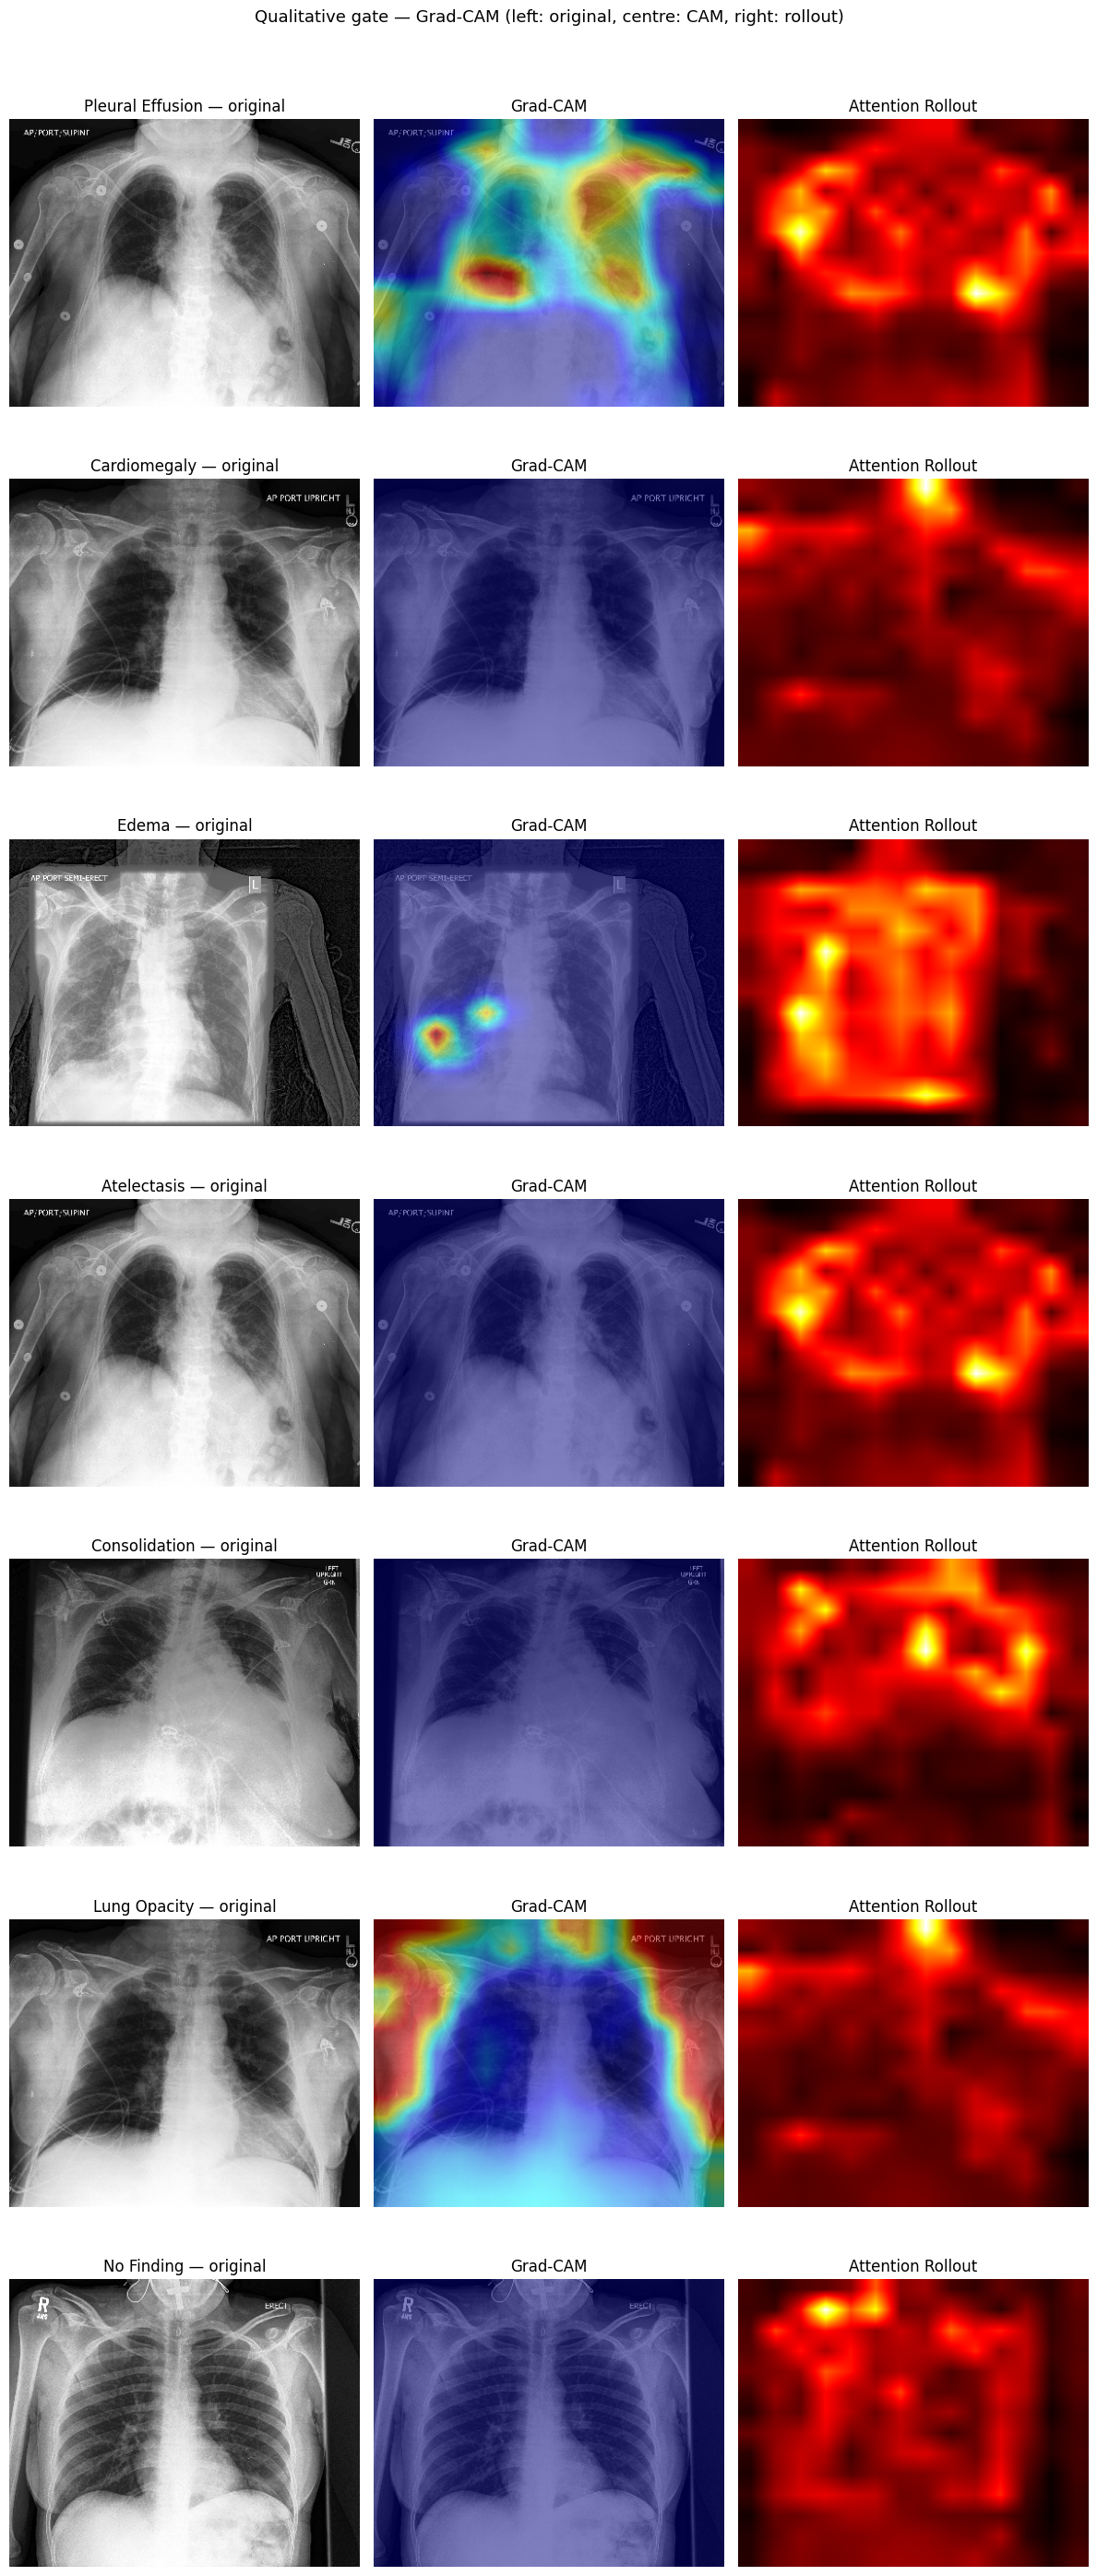

Saved: /Users/davidone/fac/diz/dizertatie_project/maps/visualizations/qualitative_gate.png


In [7]:
def overlay_cam(img_path, cam_14, alpha=0.5):
    """Overlay a 14×14 CAM on the original image. Returns RGB numpy array."""
    orig = np.array(Image.open(img_path).convert('RGB'))
    h, w = orig.shape[:2]
    heatmap = cv2.resize(cam_14.astype(np.float32), (w, h))
    heatmap = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min() + 1e-8)
    heatmap_rgb = cv2.applyColorMap((heatmap * 255).astype(np.uint8), cv2.COLORMAP_JET)
    heatmap_rgb = cv2.cvtColor(heatmap_rgb, cv2.COLOR_BGR2RGB)
    return (alpha * heatmap_rgb + (1 - alpha) * orig).astype(np.uint8)


GATE_LABELS = ['Pleural Effusion', 'Cardiomegaly', 'Edema', 'Atelectasis',
               'Consolidation', 'Lung Opacity', 'No Finding']

fig, axes = plt.subplots(len(GATE_LABELS), 3, figsize=(12, 4 * len(GATE_LABELS)))
fig.suptitle('Qualitative gate — Grad-CAM (left: original, centre: CAM, right: rollout)',
             fontsize=13, y=1.01)

for row, label in enumerate(GATE_LABELS):
    label_idx   = LABEL_COLS.index(label)
    # Find first val image that is positive for this label
    pos_indices = df_valid.index[df_valid[label] == 1.0].tolist()

    if not pos_indices:
        for ax in axes[row]:
            ax.axis('off')
            ax.set_title(f'{label} — no positives in val set')
        continue

    img_idx  = pos_indices[0]
    img_path = IMAGE_ROOT / df_valid.iloc[img_idx]['Path']
    orig     = np.array(Image.open(img_path).convert('RGB'))
    cam_overlay = overlay_cam(img_path, gradcam_maps[img_idx, label_idx])

    h, w = orig.shape[:2]
    rollout_up = cv2.resize(rollout_maps[img_idx], (w, h))
    rollout_up = (rollout_up - rollout_up.min()) / (rollout_up.max() - rollout_up.min() + 1e-8)

    axes[row, 0].imshow(orig, cmap='gray')
    axes[row, 0].set_title(f'{label} — original')
    axes[row, 1].imshow(cam_overlay)
    axes[row, 1].set_title('Grad-CAM')
    axes[row, 2].imshow(rollout_up, cmap='hot')
    axes[row, 2].set_title('Attention Rollout')
    for ax in axes[row]:
        ax.axis('off')

plt.tight_layout()
out_path = VIZ_DIR / 'qualitative_gate.png'
plt.savefig(out_path, dpi=120, bbox_inches='tight')
plt.show()
print(f'Saved: {out_path}')

## 5. Gate check

Inspect the figure above before proceeding to head pruning.

**Pass criteria:**
- Pleural Effusion: activation in lower lung fields
- Cardiomegaly: activation over the cardiac silhouette (centre-lower chest)
- Edema: bilateral lung activation, often perihilar or diffuse
- Attention Rollout: should show diffuse but structured attention, not uniform noise

If maps look anatomically correct → proceed to head pruning notebook.
If maps look random → check the reshape_transform and target_layers.

Pleural Effusion                    36 images ≥ 0.65
Cardiomegaly                        1 images ≥ 0.65
Edema                               8 images ≥ 0.65
Atelectasis                         FALLBACK — no images ≥ 0.65 (max conf=0.64)
Consolidation                       FALLBACK — no images ≥ 0.65 (max conf=0.50)
Lung Opacity                        18 images ≥ 0.65


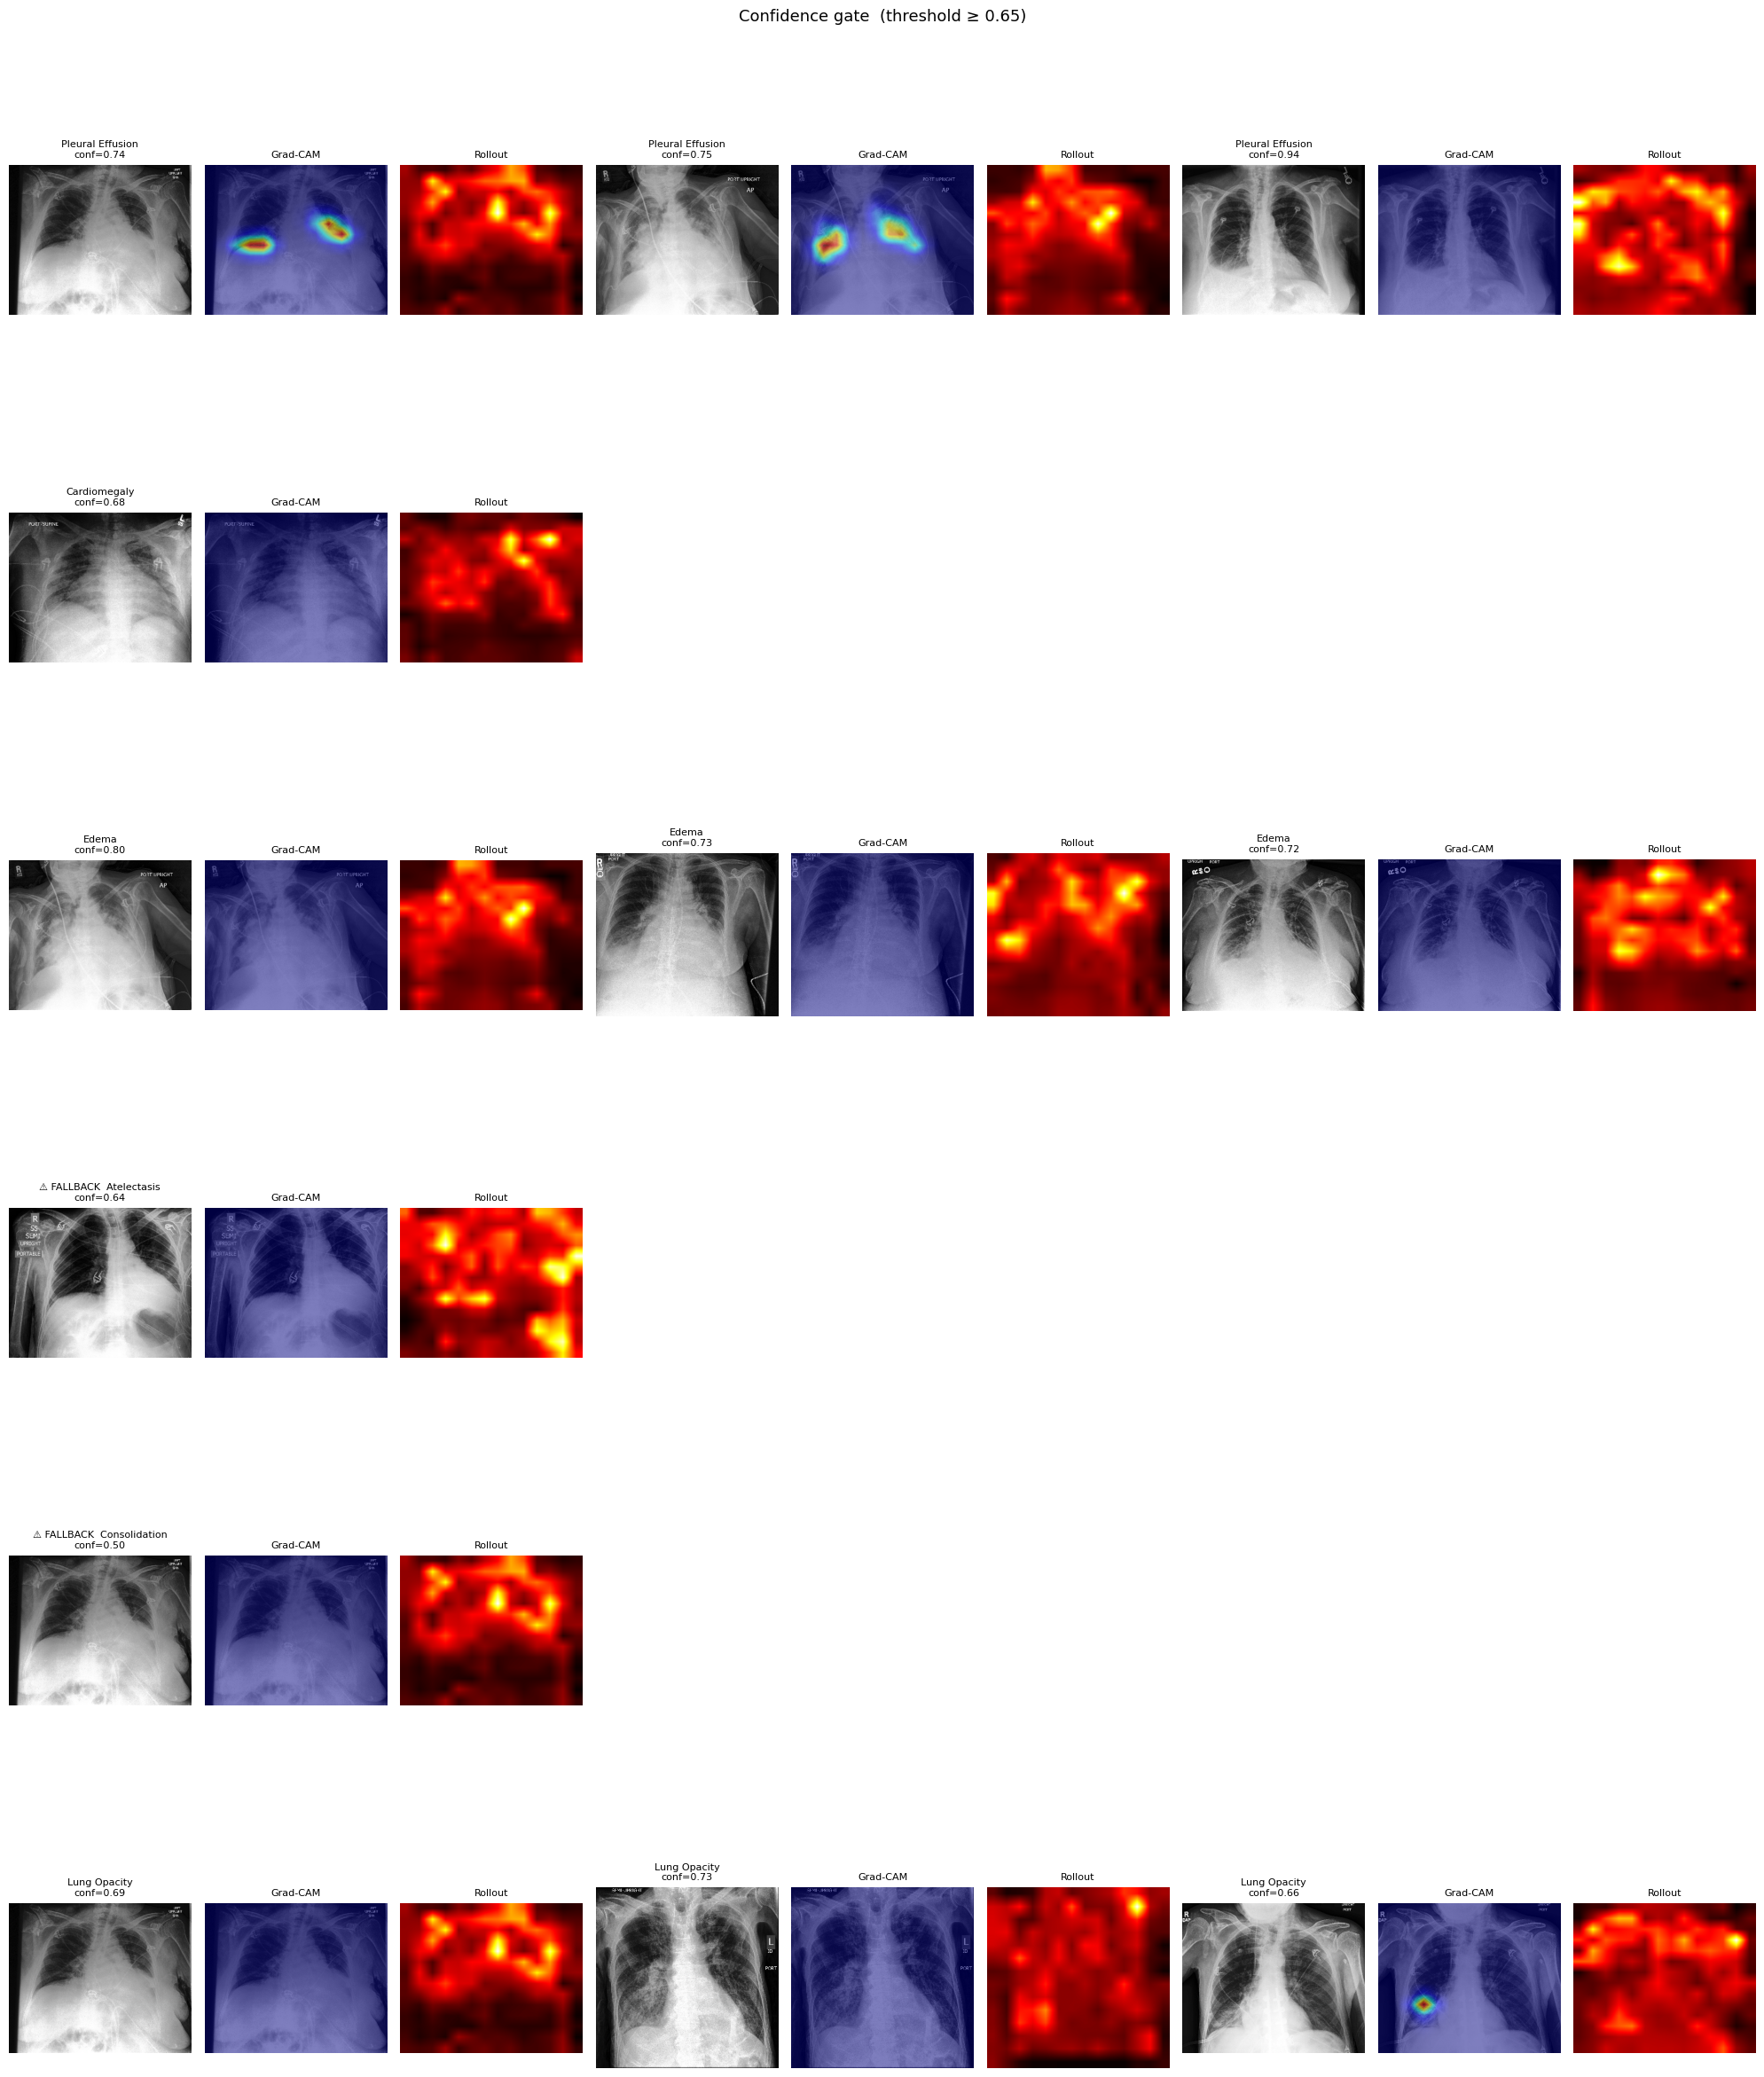


Saved: /Users/davidone/fac/diz/dizertatie_project/maps/visualizations/gate_conf65.png


In [9]:
# ── Confidence-threshold gate ─────────────────────────────────────────────────
# Shows up to 3 images where model confidence >= CONF_THRESH for that label.
# If no image clears the threshold, falls back to top-1 with a warning.
# High-confidence Grad-CAM maps are cleaner — this is the meaningful gate check.

from torch.utils.data import DataLoader as _DL

CONF_THRESH  = 0.65
CHECK_LABELS = ['Pleural Effusion', 'Cardiomegaly', 'Edema',
                'Atelectasis', 'Consolidation', 'Lung Opacity']

# Get model predictions on full val set
model.eval()
all_probs = []
with torch.no_grad():
    for imgs, *_ in _DL(val_ds, batch_size=16, shuffle=False, num_workers=0):
        all_probs.append(torch.sigmoid(model(imgs.to(DEVICE))).cpu())
all_probs = torch.cat(all_probs).numpy()   # [202, 14]

fig, axes = plt.subplots(len(CHECK_LABELS), 9,
                          figsize=(20, 4 * len(CHECK_LABELS)))
fig.suptitle(f'Confidence gate  (threshold ≥ {CONF_THRESH})',
             fontsize=13, y=1.01)

for row, label in enumerate(CHECK_LABELS):
    label_idx = LABEL_COLS.index(label)
    is_pos    = df_valid[label].values == 1.0
    probs     = all_probs[:, label_idx]

    # Images that are positive AND confident
    above     = np.where(is_pos & (probs >= CONF_THRESH))[0]
    fallback  = False
    if len(above) == 0:
        # Nothing cleared threshold — fall back to top-1 positive
        above    = np.argsort(probs * is_pos)[::-1][:1]
        fallback = True

    selected = above[:3]   # at most 3

    for col, img_idx in enumerate(selected):
        img_path    = IMAGE_ROOT / df_valid.iloc[img_idx]['Path']
        conf        = probs[img_idx]
        cam_overlay = overlay_cam(img_path, gradcam_maps[img_idx, label_idx])
        h, w        = np.array(Image.open(img_path).convert('RGB')).shape[:2]
        r_up        = cv2.resize(rollout_maps[img_idx], (w, h))
        r_up        = (r_up - r_up.min()) / (r_up.max() - r_up.min() + 1e-8)

        prefix = '⚠ FALLBACK  ' if fallback else ''
        axes[row, col*3].imshow(
            np.array(Image.open(img_path).convert('RGB')), cmap='gray')
        axes[row, col*3].set_title(
            f'{prefix}{label}\nconf={conf:.2f}', fontsize=8)
        axes[row, col*3+1].imshow(cam_overlay)
        axes[row, col*3+1].set_title('Grad-CAM', fontsize=8)
        axes[row, col*3+2].imshow(r_up, cmap='hot')
        axes[row, col*3+2].set_title('Rollout', fontsize=8)
        for ax in axes[row, col*3:col*3+3]:
            ax.axis('off')

    # Grey out unused columns if fewer than 3 images passed
    for col in range(len(selected), 3):
        for ax in axes[row, col*3:col*3+3]:
            ax.axis('off')

    n_above = len(above[above[:] >= 0]) if not fallback else 0
    status  = f'{len(above)} images ≥ {CONF_THRESH}' if not fallback \
              else f'FALLBACK — no images ≥ {CONF_THRESH} (max conf={probs[is_pos].max():.2f})'
    print(f'{label:<35} {status}')

plt.tight_layout()
out_path = VIZ_DIR / f'gate_conf{int(CONF_THRESH*100)}.png'
plt.savefig(out_path, dpi=100, bbox_inches='tight')
plt.show()
print(f'\nSaved: {out_path}')
